In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("date_inghetata.csv")
df

,temperatura,vanzari,luna,zi_saptamana
0,8,25,ianuarie,luni
1,10,35,ianuarie,marti
2,12,45,ianuarie,miercuri
3,15,55,ianuarie,joi
4,18,75,ianuarie,vineri
...,...,...,...,...
233,33,168,mai,miercuri
234,35,182,mai,joi
235,37,195,mai,vineri
236,39,208,mai,sambata


<Axes: xlabel='temperatura', ylabel='vanzari'>

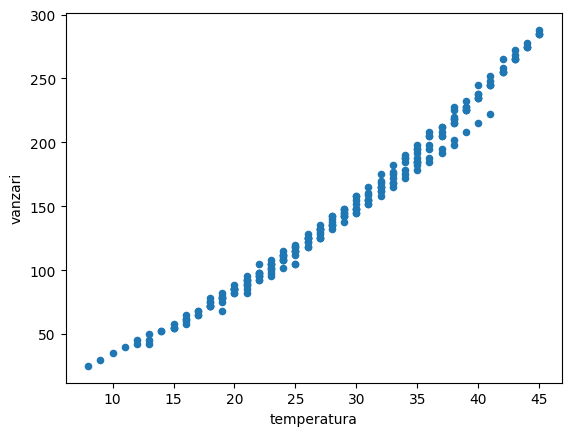

In [4]:
df.plot.scatter("temperatura", "vanzari")

<Axes: xlabel='vanzari', ylabel='temperatura'>

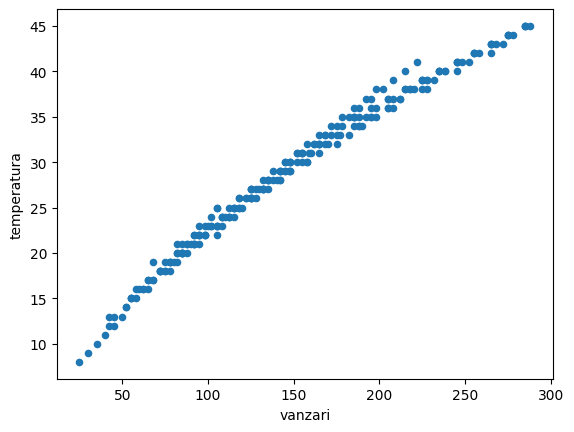

In [5]:
df.plot.scatter("vanzari", "temperatura")

In [8]:
df.keys()

Index(['temperatura', 'vanzari', 'luna', 'zi_saptamana'], dtype='object')

In [9]:
df["zi_saptamana"].unique()

array(['luni', 'marti', 'miercuri', 'joi', 'vineri', 'sambata',
       'duminica'], dtype=object)

In [10]:
df["zi_saptamana"].isin(["sambata", "duminica"])

0      False
1      False
2      False
3      False
4      False
       ...  
233    False
234    False
235    False
236     True
237     True
Name: zi_saptamana, Length: 238, dtype: bool

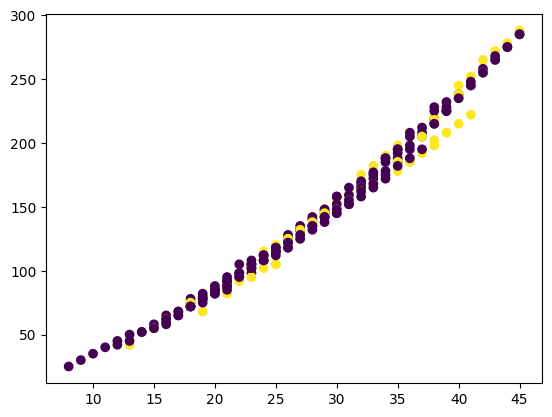

In [14]:

colors = df["zi_saptamana"].isin(["sambata", "duminica"])

plt.scatter(df["temperatura"], df["vanzari"], c=colors);

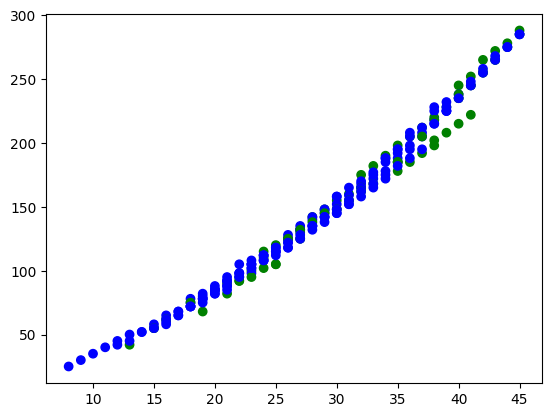

In [15]:

colors = df["zi_saptamana"].isin(["sambata", "duminica"]).map({True:"green", False:"blue"})

plt.scatter(df["temperatura"], df["vanzari"], c=colors);

In [16]:
df_weekend = df[df["zi_saptamana"].isin(["sambata", "duminica"])]
df_weekend

,temperatura,vanzari,luna,zi_saptamana
5,20,85,ianuarie,sambata
6,22,95,ianuarie,duminica
12,21,90,ianuarie,sambata
13,23,100,ianuarie,duminica
19,24,115,februarie,sambata
...,...,...,...,...
223,38,198,aprilie,duminica
229,38,202,mai,sambata
230,40,215,mai,duminica
236,39,208,mai,sambata


In [17]:
df_zile_lucratoare = df[~ df["zi_saptamana"].isin(["sambata", "duminica"])]
df_zile_lucratoare

,temperatura,vanzari,luna,zi_saptamana
0,8,25,ianuarie,luni
1,10,35,ianuarie,marti
2,12,45,ianuarie,miercuri
3,15,55,ianuarie,joi
4,18,75,ianuarie,vineri
...,...,...,...,...
231,29,142,mai,luni
232,31,155,mai,marti
233,33,168,mai,miercuri
234,35,182,mai,joi


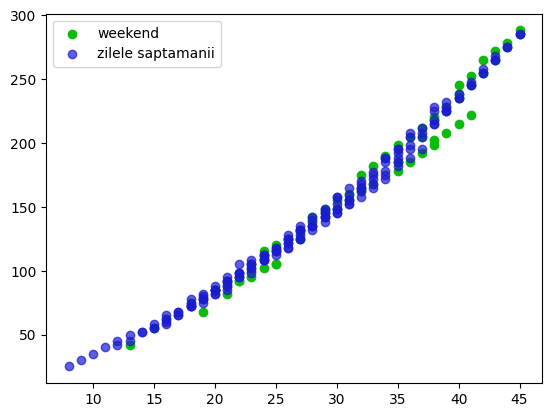

In [22]:
plt.scatter(df_weekend["temperatura"], df_weekend["vanzari"], c="#0CBB0C", label="weekend");
plt.scatter(df_zile_lucratoare["temperatura"], df_zile_lucratoare["vanzari"], c="#1B1BD1", alpha=0.7, label="zilele saptamanii");
plt.legend();


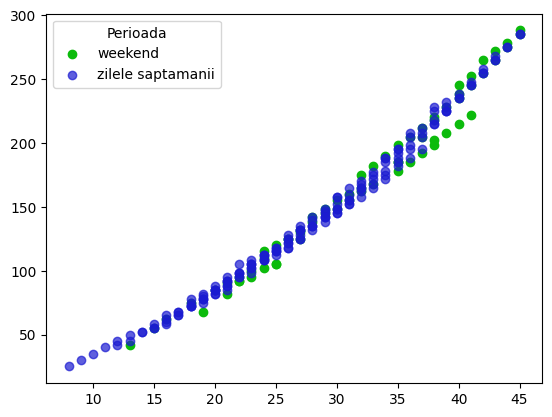

In [23]:
plt.scatter(df_weekend["temperatura"], df_weekend["vanzari"], c="#0CBB0C", label="weekend");
plt.scatter(df_zile_lucratoare["temperatura"], df_zile_lucratoare["vanzari"], c="#1B1BD1", alpha=0.7, label="zilele saptamanii");
plt.legend(title="Perioada");

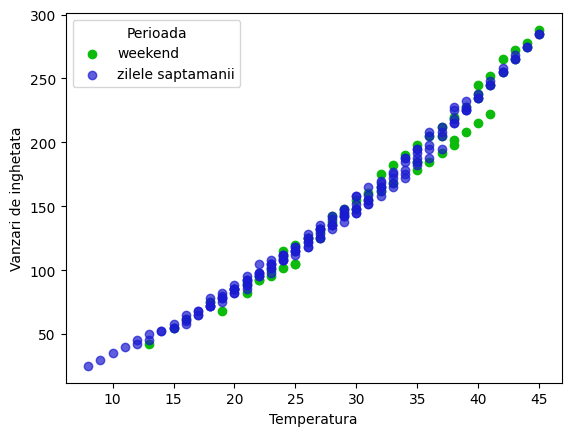

In [25]:
plt.scatter(df_weekend["temperatura"], df_weekend["vanzari"], c="#0CBB0C", label="weekend");
plt.scatter(df_zile_lucratoare["temperatura"], df_zile_lucratoare["vanzari"], c="#1B1BD1", alpha=0.7, label="zilele saptamanii");
plt.legend(title="Perioada");
plt.xlabel("Temperatura");
plt.ylabel("Vanzari de inghetata");

# Calculează vânzările medii pe fiecare lună și reprezintă-le printr-un line plot. 

In [27]:
df.head(2)

,temperatura,vanzari,luna,zi_saptamana
0,8,25,ianuarie,luni
1,10,35,ianuarie,marti


In [28]:
df["luna"].unique()

array(['ianuarie', 'februarie', 'martie', 'aprilie', 'mai', 'iunie',
       'iulie', 'august', 'septembrie', 'octombrie', 'noiembrie',
       'decembrie'], dtype=object)

In [29]:
LUNI_CALENDARISTICE = ['ianuarie', 'februarie', 'martie', 'aprilie', 'mai', 'iunie',
       'iulie', 'august', 'septembrie', 'octombrie', 'noiembrie',
       'decembrie']

In [33]:
monthly_sales = df.groupby("luna")["vanzari"].mean()
monthly_sales

luna
aprilie       150.071429
august        254.285714
decembrie      79.785714
februarie      82.785714
ianuarie       81.714286
iulie         238.642857
iunie         208.500000
mai           175.821429
martie        120.642857
noiembrie     116.571429
octombrie     168.214286
septembrie    222.214286
Name: vanzari, dtype: float64

In [34]:
type(monthly_sales)

pandas.core.series.Series

In [36]:
monthly_sales = monthly_sales.reindex(LUNI_CALENDARISTICE)
monthly_sales

luna
ianuarie       81.714286
februarie      82.785714
martie        120.642857
aprilie       150.071429
mai           175.821429
iunie         208.500000
iulie         238.642857
august        254.285714
septembrie    222.214286
octombrie     168.214286
noiembrie     116.571429
decembrie      79.785714
Name: vanzari, dtype: float64

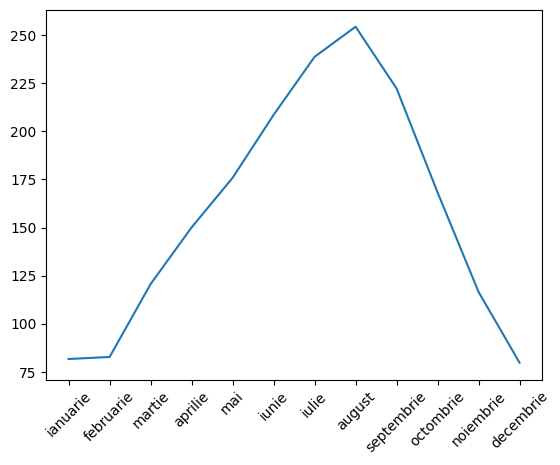

In [42]:
plt.plot(monthly_sales)
plt.xticks(rotation=45);

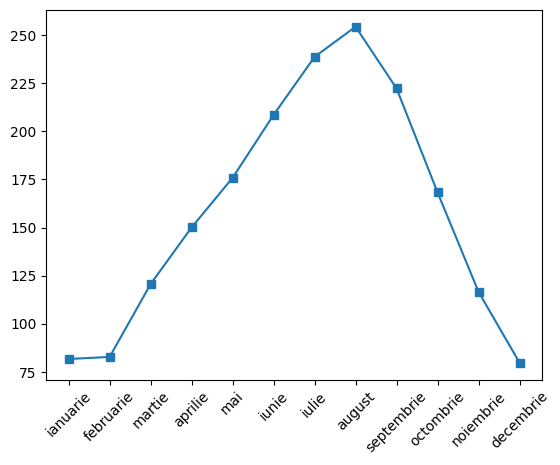

In [43]:
plt.plot(monthly_sales, marker="s")
plt.xticks(rotation=45);

# Documentatia pentru markere https://matplotlib.org/stable/api/_as_gen/matplotlib.markers.MarkerStyle.html

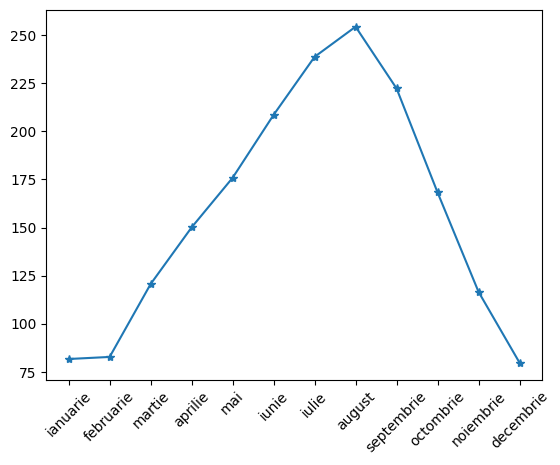

In [44]:
plt.plot(monthly_sales, marker="*")
plt.xticks(rotation=45);

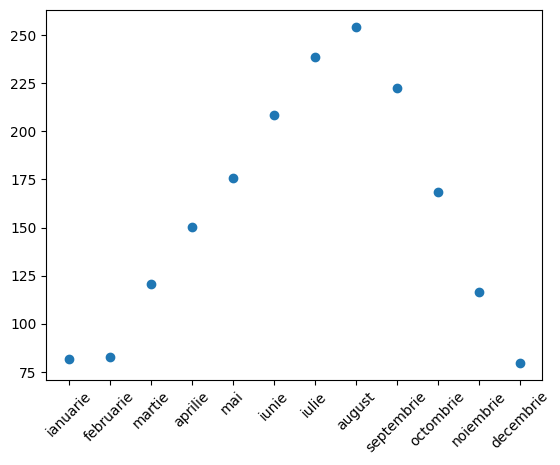

In [51]:
plt.scatter(monthly_sales.index, monthly_sales)
plt.xticks(rotation=45);

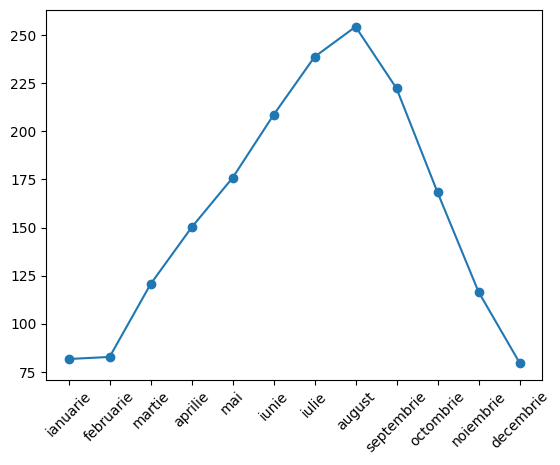

In [52]:
plt.scatter(monthly_sales.index, monthly_sales)
plt.plot(monthly_sales.index, monthly_sales)
plt.xticks(rotation=45);

Markerele se afla la matplotlib.markers.MarkerStyle

In [45]:
from  matplotlib.markers import MarkerStyle

In [47]:
print(MarkerStyle.__doc__)


A class representing marker types.

Instances are immutable. If you need to change anything, create a new
instance.

Attributes
----------
markers : dict
    All known markers.
filled_markers : tuple
    All known filled markers. This is a subset of *markers*.
fillstyles : tuple
    The supported fillstyles.

